--- Generating MONTHLY Comparative Chart: History vs ABM vs SARIMA vs LSTM ---
--- Using SUM of monthly consumption (not annual average) ---
ABM scenarios loaded: 18 scenarios, 120 monthly records
Historical data loaded: 132 monthly records
Historical consumption range: 152972 - 220737 m³/month
SARIMA data loaded: 120 monthly records
LSTM data loaded: 120 monthly records
LSTM consumption range: 173567 - 186941 m³/month



✓ Success! Monthly comparison chart saved at: ..\figuras\figure-result-simulation-final-comparison-monthly.pdf

--- Statistical Summary (Monthly Raw Consumption) ---
Historical period: 2015 - 2025
Historical mean monthly: 184.8k m³
Historical std deviation: 11.6k m³
Historical min: 153.0k m³
Historical max: 220.7k m³

SARIMA forecast (2026-2035):
  Mean: 188.7k m³
  Min: 174.9k m³
  Max: 199.1k m³

LSTM forecast (2026-2035):
  Mean: 180.0k m³
  Min: 173.6k m³
  Max: 186.9k m³

ABM scenarios (2026-2035):
  Mean (all scenarios): 187.6k m³
  Min: 183.3k m³
  Max: 196.4k m³


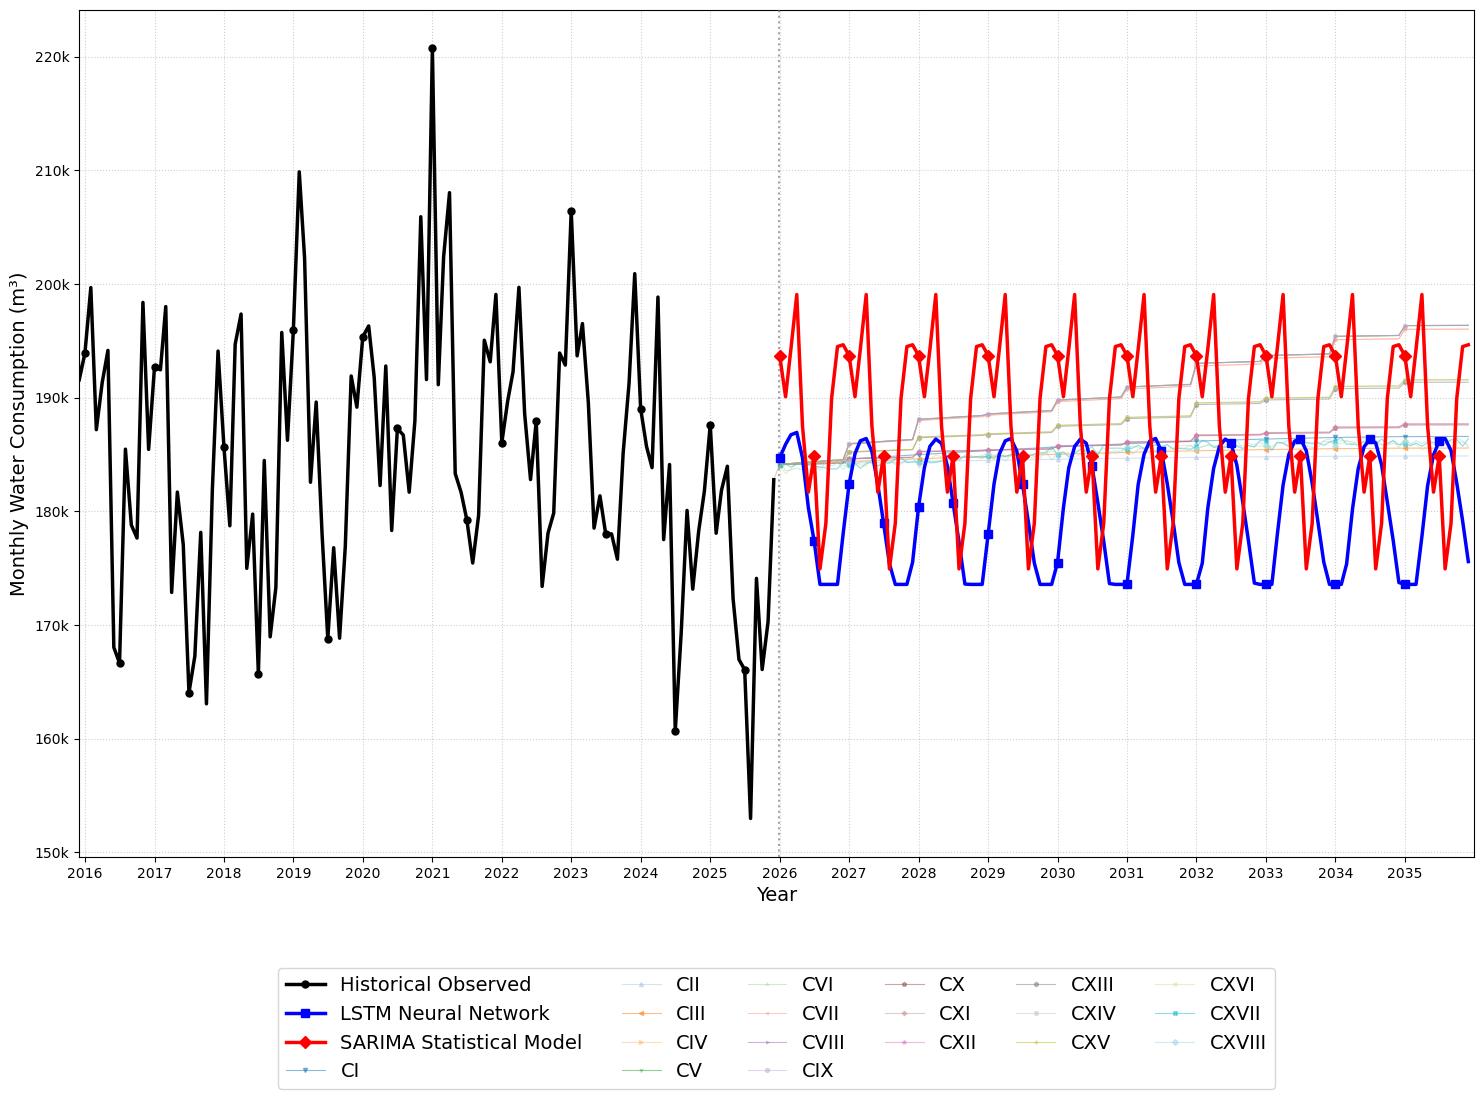

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
BASE_PATH = '..' 

# Input Filenames
SCENARIO_FILE = 'consumo_previsto_todos_cenarios_2026_2035.csv'
HISTORICAL_FILE = 'Tabela_consumo_Itapua_120m_por_mes.csv'
LSTM_FILE = 'previsoes_futuras_2026_2035.csv'
SARIMA_FILE = 'previsao_consumo_sarima_2026_2035.csv'

# Output Configuration
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-result-simulation-final-comparison-monthly.pdf'

# Search Directories
INPUT_DIR_RESULTS = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')

def main():
    print("--- Generating MONTHLY Comparative Chart: History vs ABM vs SARIMA vs LSTM ---")
    print("--- Using SUM of monthly consumption (not annual average) ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    
    # A. Load ABM Scenarios
    path_scen = os.path.join(INPUT_DIR_RESULTS, SCENARIO_FILE)
    df_scenarios = pd.read_csv(path_scen, sep=';', decimal=',')
    
    # Create Date column from Mes and Ano
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(
            df_scenarios['Ano'].astype(str) + '-' + 
            df_scenarios['Mes'].astype(str) + '-01'
        )
    
    # Identify scenario columns (exclude metadata columns)
    exclude_cols = ['Mes', 'Ano', 'Mes_Ano', 'Date']
    scenario_cols = [c for c in df_scenarios.columns if c not in exclude_cols]
    
    # Filter to desired period (2016-2035)
    df_scenarios = df_scenarios[df_scenarios['Date'] < pd.to_datetime('2036-01-01')]
    print(f"ABM scenarios loaded: {len(scenario_cols)} scenarios, {len(df_scenarios)} monthly records")
    
    # Convert scenario values to numeric (they have comma as decimal)
    for col in scenario_cols:
        df_scenarios[col] = pd.to_numeric(df_scenarios[col], errors='coerce')

    # B. Load Historical Data
    path_hist = os.path.join(INPUT_DIR_INCLUDES, HISTORICAL_FILE)
    df_historical = pd.read_csv(path_hist, sep=';')
    df_historical['Date'] = pd.to_datetime(df_historical['data'])
    df_historical.rename(columns={'consumo': 'Hist'}, inplace=True)
    print(f"Historical data loaded: {len(df_historical)} monthly records")
    print(f"Historical consumption range: {df_historical['Hist'].min():.0f} - {df_historical['Hist'].max():.0f} m³/month")

    # C. Load SARIMA Forecast
    path_sarima = os.path.join(INPUT_DIR_MODELS, SARIMA_FILE)
    df_sarima = None
    if os.path.exists(path_sarima):
        df_sarima = pd.read_csv(path_sarima)
        
        # Detect date column
        if 'Date' in df_sarima.columns:
            df_sarima['Date'] = pd.to_datetime(df_sarima['Date'])
        elif 'data' in df_sarima.columns:
            df_sarima['Date'] = pd.to_datetime(df_sarima['data'])
        
        # Identify forecast column
        if 'Projected_Consumption' in df_sarima.columns:
            df_sarima.rename(columns={'Projected_Consumption': 'SARIMA'}, inplace=True)
        elif 'forecast' in df_sarima.columns:
            df_sarima.rename(columns={'forecast': 'SARIMA'}, inplace=True)
        
        df_sarima = df_sarima[(df_sarima['Date'] >= '2026-01-01') & (df_sarima['Date'] <= '2035-12-31')]
        print(f"SARIMA data loaded: {len(df_sarima)} monthly records")
    else:
        print(f"Aviso: {SARIMA_FILE} não encontrado em {path_sarima}")

    # D. Load LSTM Forecast
    path_lstm = os.path.join(INPUT_DIR_MODELS, LSTM_FILE)
    df_lstm = None
    if os.path.exists(path_lstm):
        df_lstm = pd.read_csv(path_lstm, sep=",")
        
        # Detect date column (different possible names)
        if 'Data' in df_lstm.columns:
            df_lstm['Date'] = pd.to_datetime(df_lstm['Data'])
        elif 'date' in df_lstm.columns:
            df_lstm['Date'] = pd.to_datetime(df_lstm['date'])
        elif 'mes' in df_lstm.columns and 'ano' in df_lstm.columns:
            df_lstm['Date'] = pd.to_datetime(
                df_lstm['ano'].astype(str) + '-' + 
                df_lstm['mes'].astype(str) + '-01'
            )
        
        # Identify forecast column
        if 'Valor Previsto' in df_lstm.columns:
            df_lstm.rename(columns={'Valor Previsto': 'LSTM'}, inplace=True)
        elif 'predicted' in df_lstm.columns:
            df_lstm.rename(columns={'predicted': 'LSTM'}, inplace=True)
        elif 'LSTM' in df_lstm.columns:
            pass  # Already has correct name
        
        # Convert to numeric if needed
        if 'LSTM' in df_lstm.columns:
            df_lstm['LSTM'] = pd.to_numeric(df_lstm['LSTM'], errors='coerce')
        
        df_lstm = df_lstm[(df_lstm['Date'] >= '2026-01-01') & (df_lstm['Date'] <= '2035-12-31')]
        print(f"LSTM data loaded: {len(df_lstm)} monthly records")
        if len(df_lstm) > 0:
            print(f"LSTM consumption range: {df_lstm['LSTM'].min():.0f} - {df_lstm['LSTM'].max():.0f} m³/month")
    else:
        print(f"Aviso: {LSTM_FILE} não encontrado em {path_lstm}")

    # ==========================================
    # 3. Plotting (MONTHLY - RAW VALUES)
    # ==========================================
    fig, ax = plt.subplots(figsize=(18, 11))

    # --- A. Transition Connection (Last Historical to First ABM) ---
    last_hist = df_historical.iloc[-1]
    first_scen = df_scenarios[df_scenarios['Date'] >= '2025-01-01'].iloc[0] if len(df_scenarios) > 0 else None
    
    if first_scen is not None:
        ax.plot([last_hist['Date'], first_scen['Date']], 
                [last_hist['Hist'], first_scen[scenario_cols[0]]], 
                color='gray', linestyle='-', linewidth=1.0, zorder=8, alpha=0.3)

    # --- B. ABM Scenarios Cloud (Monthly - RAW VALUES) ---
    markers_list = ['v', '^', '<', '>', '1', '2', '3', '4', '8', 'p', 'P', '*', 'h', 'H', '+', 'x', 'X', 'D']
    colors = plt.cm.tab20(np.linspace(0, 1, len(scenario_cols)))
    
    for idx, col in enumerate(scenario_cols):
        scen_id = col.split('_')[0] if '_' in col else col[:4]
        ax.plot(df_scenarios['Date'], df_scenarios[col], label=scen_id, color=colors[idx],
                linestyle='-', linewidth=0.8, alpha=0.5, 
                marker=markers_list[idx % len(markers_list)], markersize=3, markevery=12)

    # --- C. SARIMA Forecast (Red) ---
    if df_sarima is not None and len(df_sarima) > 0:
        ax.plot(df_sarima['Date'], df_sarima['SARIMA'], label='SARIMA Statistical Model', color='red',
                linestyle='-', linewidth=2.5, marker='D', markersize=6, markevery=6, zorder=21)

    # --- D. LSTM Forecast (Blue) ---
    if df_lstm is not None and len(df_lstm) > 0:
        ax.plot(df_lstm['Date'], df_lstm['LSTM'], label='LSTM Neural Network', color='blue',
                linestyle='-', linewidth=2.5, marker='s', markersize=6, markevery=6, zorder=20)

    # --- E. Historical Data (Black) ---
    ax.plot(df_historical['Date'], df_historical['Hist'], label='Historical Observed', color='black',
            linestyle='-', linewidth=2.5, marker='o', markersize=5, markevery=6, zorder=25)

    # ==========================================
    # 4. Final Formatting
    # ==========================================
    ax.set_ylabel('Monthly Water Consumption (m³)', fontsize=14)
    ax.set_xlabel('Year', fontsize=14)
    
    # Format x-axis: show every year
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # Format y-axis with 'k' suffix (thousands)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    
    # Set x-axis limits
    ax.set_xlim(pd.Timestamp('2015-12-01'), pd.Timestamp('2035-12-31'))
    
    # Add vertical line at transition (2025-2026 boundary)
    ax.axvline(pd.Timestamp('2025-12-31'), color='gray', linestyle=':', linewidth=1.5, alpha=0.7, zorder=5)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Legend - reordered to show main models first
    handles, labels = ax.get_legend_handles_labels()
    main_order = ['Historical Observed', 'LSTM Neural Network', 'SARIMA Statistical Model']
    
    new_handles = []
    new_labels = []
    for m in main_order:
        if m in labels:
            idx = labels.index(m)
            new_handles.append(handles[idx])
            new_labels.append(labels[idx])
    
    for i, l in enumerate(labels):
        if l not in main_order:
            new_handles.append(handles[i])
            new_labels.append(l)
    
    plt.legend(new_handles, new_labels, loc='upper center', bbox_to_anchor=(0.5, -0.12), 
               ncol=6, fontsize=14, frameon=True)
    
    plt.subplots_adjust(bottom=0.18, top=0.95)
    
    # Save
    if not os.path.exists(OUTPUT_DIR): 
        os.makedirs(OUTPUT_DIR)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    print(f"\n✓ Success! Monthly comparison chart saved at: {save_path}")
    
    # ==========================================
    # 5. Statistical Summary
    # ==========================================
    print("\n--- Statistical Summary (Monthly Raw Consumption) ---")
    print(f"Historical period: {df_historical['Date'].min().year} - {df_historical['Date'].max().year}")
    print(f"Historical mean monthly: {df_historical['Hist'].mean()/1000:.1f}k m³")
    print(f"Historical std deviation: {df_historical['Hist'].std()/1000:.1f}k m³")
    print(f"Historical min: {df_historical['Hist'].min()/1000:.1f}k m³")
    print(f"Historical max: {df_historical['Hist'].max()/1000:.1f}k m³")
    
    if df_sarima is not None:
        print(f"\nSARIMA forecast (2026-2035):")
        print(f"  Mean: {df_sarima['SARIMA'].mean()/1000:.1f}k m³")
        print(f"  Min: {df_sarima['SARIMA'].min()/1000:.1f}k m³")
        print(f"  Max: {df_sarima['SARIMA'].max()/1000:.1f}k m³")
    
    if df_lstm is not None:
        print(f"\nLSTM forecast (2026-2035):")
        print(f"  Mean: {df_lstm['LSTM'].mean()/1000:.1f}k m³")
        print(f"  Min: {df_lstm['LSTM'].min()/1000:.1f}k m³")
        print(f"  Max: {df_lstm['LSTM'].max()/1000:.1f}k m³")
    
    # Calculate ABM scenario ranges
    abm_values = []
    for col in scenario_cols:
        abm_values.extend(df_scenarios[col].values)
    print(f"\nABM scenarios (2026-2035):")
    print(f"  Mean (all scenarios): {np.mean(abm_values)/1000:.1f}k m³")
    print(f"  Min: {np.min(abm_values)/1000:.1f}k m³")
    print(f"  Max: {np.max(abm_values)/1000:.1f}k m³")
    
    plt.show()

if __name__ == "__main__":
    main()